In [3]:
import os

In [4]:
import pandas as pd

In [5]:
df=pd.read_csv("data/LengthOfStay.csv")

In [5]:
df.shape


(100000, 28)

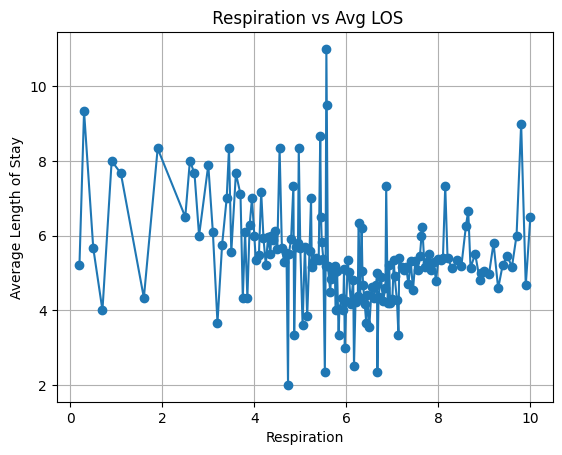

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
avg_los = df.groupby('respiration')['lengthofstay'].mean()

plt.figure()
avg_los.plot(kind='line', marker='o')
plt.xlabel('Respiration')
plt.ylabel('Average Length of Stay')
plt.title(' Respiration vs Avg LOS')
plt.grid()
plt.show()

In [6]:
df.head()

,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


In [7]:
df.isnull().sum()

eid                           0
vdate                         0
rcount                        0
gender                        0
dialysisrenalendstage         0
asthma                        0
irondef                       0
pneum                         0
substancedependence           0
psychologicaldisordermajor    0
depress                       0
psychother                    0
fibrosisandother              0
malnutrition                  0
hemo                          0
hematocrit                    0
neutrophils                   0
sodium                        0
glucose                       0
bloodureanitro                0
creatinine                    0
bmi                           0
pulse                         0
respiration                   0
secondarydiagnosisnonicd9     0
discharged                    0
facid                         0
lengthofstay                  0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop(columns=["eid"], inplace=True, errors="ignore")


In [10]:
for col in ["vdate", "discharged"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

In [11]:
df.head()

,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,2012-08-29,0,F,0,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,2012-09-01,B,3
1,2012-05-26,5+,F,0,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,2012-06-02,A,7
2,2012-09-22,1,F,0,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,2012-09-25,B,3
3,2012-08-09,0,F,0,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,2012-08-10,A,1
4,2012-12-20,0,F,0,0,0,1,0,1,0,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,2012-12-24,E,4


In [12]:
if "vdate" in df.columns:
        df["admit_dayofweek"]  = df["vdate"].dt.dayofweek        # 0=Mon..6=Sun
        df["admit_month"]      = df["vdate"].dt.month
        df["admit_is_weekend"] = (df["admit_dayofweek"] >= 5).astype(int)
        df["admit_quarter"]    = df["vdate"].dt.quarter

In [13]:
df["admit_season"] = df["admit_month"].map(
            {12:1, 1:1, 2:1, 3:2, 4:2, 5:2,
             6:3, 7:3, 8:3, 9:4, 10:4, 11:4}
        )

In [14]:
df.drop(columns=["vdate", "discharged"], inplace=True, errors="ignore")

In [15]:
# condition_flags = [
#         "dialysisrenalendstage", "asthma", "irondef", "pneum",
#         "substancedependence", "psychologicaldisordermajor",
#         "depress", "psychother", "fibrosisandother",
#         "malnutrition", "hemo"
#     ]
# existing_flags = [c for c in condition_flags if c in df.columns]

#     # Flags come as "Yes"/"No" strings — convert to 0/1
# for col in existing_flags:
#     df[col] = (df[col].astype(str).str.strip().str.lower() == "yes").astype(int)

# df["comorbidity_score"] = df[existing_flags].sum(axis=1)
# print(f"  comorbidity_score range : {df['comorbidity_score'].min()}–{df['comorbidity_score'].max()}")

In [16]:
condition_flags = [
    "dialysisrenalendstage", "asthma", "irondef", "pneum",
    "substancedependence", "psychologicaldisordermajor",
    "depress", "psychother", "fibrosisandother",
    "malnutrition", "hemo"
]

existing_flags = [c for c in condition_flags if c in df.columns]

for col in existing_flags:
    df[col] = df[col].astype(str).str.strip().str.lower()

    df[col] = df[col].map({
        "yes": 1, "1": 1, "true": 1,
        "no": 0, "0": 0, "false": 0
    })

    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

df["comorbidity_score"] = df[existing_flags].sum(axis=1)

print(df[existing_flags].sum())  # total 1s per column
print(f"range: {df['comorbidity_score'].min()}–{df['comorbidity_score'].max()}")

dialysisrenalendstage          3642
asthma                         3527
irondef                        9494
pneum                          3945
substancedependence            6306
psychologicaldisordermajor    23904
depress                        5166
psychother                     4939
fibrosisandother                479
malnutrition                   4948
hemo                           8000
dtype: int64
range: 0–9


In [17]:
if "hematocrit" in df.columns and "hemoglobin" in df.columns:
        df["hematocrit_hemo_ratio"] = df["hematocrit"] / (df["hemoglobin"] + 1e-5)

if "sodium" in df.columns and "glucose" in df.columns:
        df["metabolic_stress_index"] = (
            (df["sodium"] - 140).abs() + (df["glucose"] - 100).abs()
        )

if "bloodureanitro" in df.columns and "creatinine" in df.columns:
        # BUN/Creatinine ratio — standard kidney function indicator
        df["bun_creatinine_ratio"] = (
            df["bloodureanitro"] / (df["creatinine"] + 1e-5)
        )

In [18]:
df.head()

,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,...,facid,lengthofstay,admit_dayofweek,admit_month,admit_is_weekend,admit_quarter,admit_season,comorbidity_score,metabolic_stress_index,bun_creatinine_ratio
0,0,F,0,0,0,0,0,0,0,0,...,B,3,2,8,0,3,3,0,92.838050,8.628548
1,5+,F,0,0,0,0,0,0,0,0,...,A,7,5,5,1,2,2,0,9.189801,8.481995
2,1,F,0,0,0,0,0,0,0,0,...,B,3,5,9,1,3,4,0,37.472010,11.259568
3,0,F,0,0,0,0,0,0,0,0,...,A,1,3,8,0,3,3,0,64.383005,13.232300
4,0,F,0,0,0,1,0,1,0,0,...,E,4,3,12,0,4,1,2,6.478510,9.252821


In [19]:
if "rcount" in df.columns:
        df["rcount"] = pd.to_numeric(df["rcount"], errors="coerce").fillna(0)
        df["is_frequent_readmit"] = (df["rcount"] >= 2).astype(int)

In [20]:
if "bmi" in df.columns:
        df["bmi_category"] = pd.cut(
            df["bmi"],
            bins=[0, 18.5, 25, 30, 100],
            labels=["underweight", "normal", "overweight", "obese"]
        )

In [21]:
df.head()

,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,...,admit_dayofweek,admit_month,admit_is_weekend,admit_quarter,admit_season,comorbidity_score,metabolic_stress_index,bun_creatinine_ratio,is_frequent_readmit,bmi_category
0,0.0,F,0,0,0,0,0,0,0,0,...,2,8,0,3,3,0,92.838050,8.628548,0,obese
1,0.0,F,0,0,0,0,0,0,0,0,...,5,5,1,2,2,0,9.189801,8.481995,0,overweight
2,1.0,F,0,0,0,0,0,0,0,0,...,5,9,1,3,4,0,37.472010,11.259568,0,overweight
3,0.0,F,0,0,0,0,0,0,0,0,...,3,8,0,3,3,0,64.383005,13.232300,0,overweight
4,0.0,F,0,0,0,1,0,1,0,0,...,3,12,0,4,1,2,6.478510,9.252821,0,obese


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

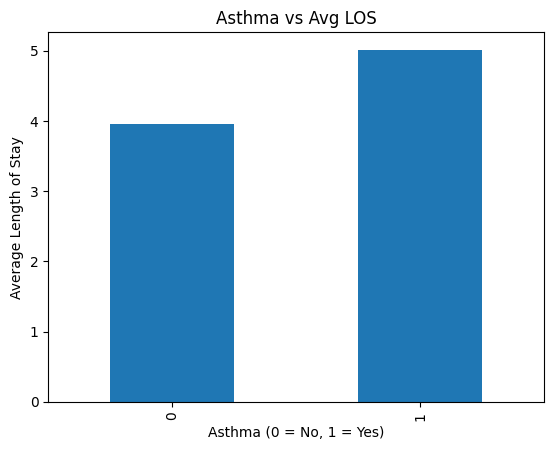

In [24]:
avg_los = df.groupby('asthma')['lengthofstay'].mean()

plt.figure()
avg_los.plot(kind='bar')
plt.xlabel('Asthma (0 = No, 1 = Yes)')
plt.ylabel('Average Length of Stay')
plt.title('Asthma vs Avg LOS')
plt.show()

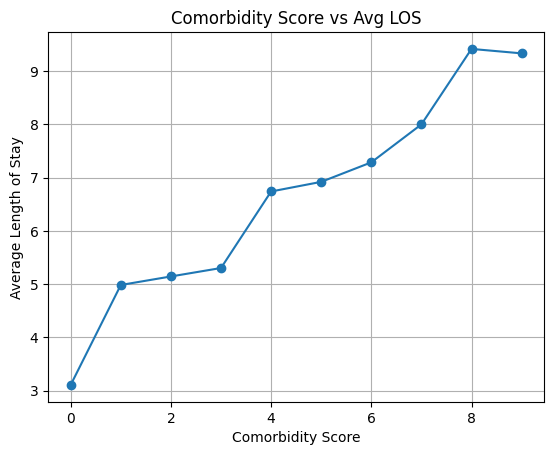

In [ ]:
avg_los = df.groupby('comorbidity_score')['lengthofstay'].mean()

plt.figure()
avg_los.plot(kind='line', marker='o')
plt.xlabel('Comorbidity Score')
plt.ylabel('Average Length of Stay')
plt.title('Comorbidity Score vs Avg LOS')
plt.grid()
plt.show()

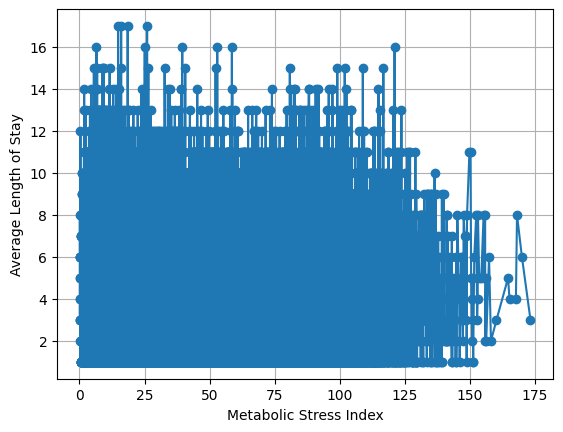

In [30]:
avg_los = df.groupby('metabolic_stress_index')['lengthofstay'].mean()

plt.figure()
avg_los.plot(kind='line', marker='o')
plt.xlabel('Metabolic Stress Index')
plt.ylabel('Average Length of Stay')
plt.grid()
plt.show()

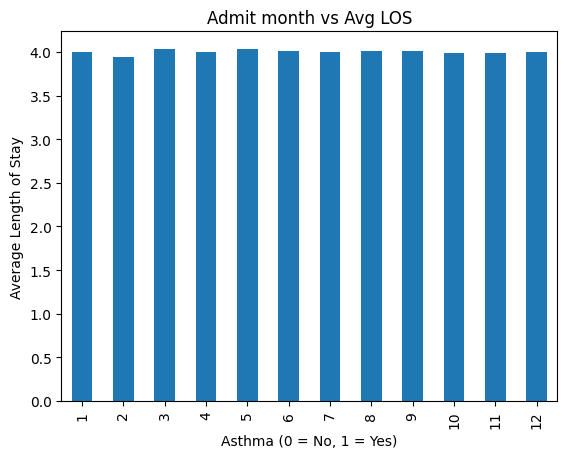

In [31]:
avg_los = df.groupby('admit_month')['lengthofstay'].mean()

plt.figure()
avg_los.plot(kind='bar')
plt.xlabel('Asthma (0 = No, 1 = Yes)')
plt.ylabel('Average Length of Stay')
plt.title('Admit month vs Avg LOS')
plt.show()

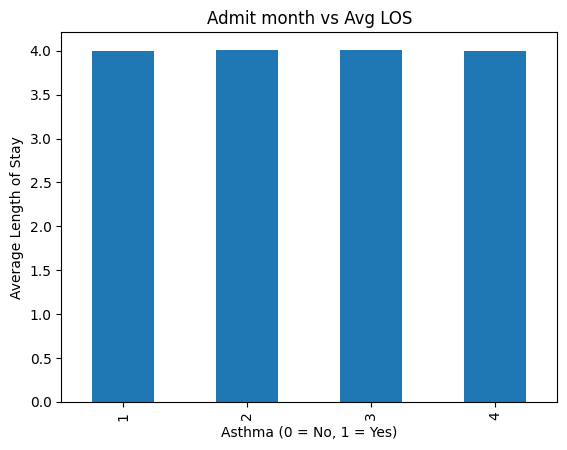

In [ ]:
avg_los = df.groupby('is_frequent')['lengthofstay'].mean()

plt.figure()
avg_los.plot(kind='bar')
plt.xlabel('Asthma (0 = No, 1 = Yes)')
plt.ylabel('Average Length of Stay')
plt.title('Admit month vs Avg LOS')
plt.show()

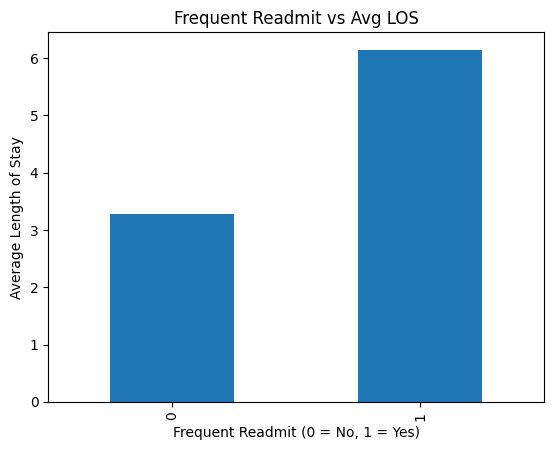

In [33]:
avg_los = df.groupby('is_frequent_readmit')['lengthofstay'].mean()

plt.figure()
avg_los.plot(kind='bar')
plt.xlabel('Frequent Readmit (0 = No, 1 = Yes)')
plt.ylabel('Average Length of Stay')
plt.title('Frequent Readmit vs Avg LOS')
plt.show()

In [34]:
df.columns

Index(['rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef',
       'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress',
       'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit',
       'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine',
       'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'facid',
       'lengthofstay', 'admit_dayofweek', 'admit_month', 'admit_is_weekend',
       'admit_quarter', 'admit_season', 'comorbidity_score',
       'metabolic_stress_index', 'bun_creatinine_ratio', 'is_frequent_readmit',
       'bmi_category'],
      dtype='str')

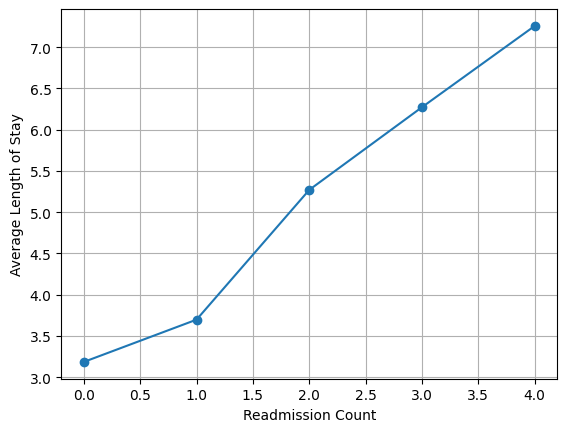

In [35]:
avg_los = df.groupby('rcount')['lengthofstay'].mean()

plt.figure()
avg_los.plot(kind='line', marker='o')
plt.xlabel('Readmission Count')
plt.ylabel('Average Length of Stay')
plt.grid()
plt.show()

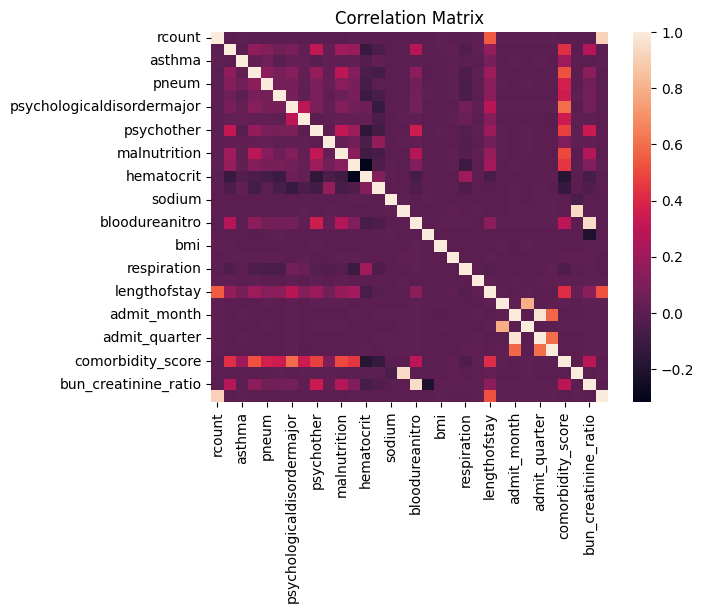

In [36]:

corr = df.corr(numeric_only=True)

plt.figure()
sns.heatmap(corr, annot=False)
plt.title("Correlation Matrix")
plt.show()

In [40]:
print(df.corr(numeric_only=True)['lengthofstay'].sort_values(ascending=False))

lengthofstay                  1.000000
rcount                        0.551166
is_frequent_readmit           0.524267
comorbidity_score             0.417276
psychologicaldisordermajor    0.286724
hemo                          0.217696
irondef                       0.193838
psychother                    0.191695
malnutrition                  0.174397
dialysisrenalendstage         0.169695
bun_creatinine_ratio          0.150904
bloodureanitro                0.148290
substancedependence           0.147886
pneum                         0.135461
depress                       0.121408
asthma                        0.082005
fibrosisandother              0.062131
metabolic_stress_index        0.025230
pulse                         0.006683
secondarydiagnosisnonicd9     0.006540
admit_is_weekend              0.003931
admit_dayofweek               0.002861
admit_season                  0.001266
admit_month                   0.000629
bmi                           0.000132
admit_quarter            

In [45]:
def drop_unused_columns(df):
    cols_to_drop = [
        "admit_dayofweek",
        "admit_month",
        "admit_season",
        "admit_quarter",
        "bmi",
        "glucose",
        "sodium",
        "creatinine",
        "neutrophils",
        "respiration",
        "hematocrit","is_frequent_readmit"
    ]
    return df.drop(columns=cols_to_drop,inplace=True, errors="ignore")

In [46]:
drop_unused_columns(df)

In [48]:
df.head()

,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,...,bloodureanitro,pulse,secondarydiagnosisnonicd9,facid,lengthofstay,admit_is_weekend,comorbidity_score,metabolic_stress_index,bun_creatinine_ratio,bmi_category
0,0.0,F,0,0,0,0,0,0,0,0,...,12.0,96,4,B,3,0,0,92.838050,8.628548,obese
1,0.0,F,0,0,0,0,0,0,0,0,...,8.0,61,1,A,7,1,0,9.189801,8.481995,overweight
2,1.0,F,0,0,0,0,0,0,0,0,...,12.0,64,2,B,3,1,0,37.472010,11.259568,overweight
3,0.0,F,0,0,0,0,0,0,0,0,...,12.0,76,1,A,1,0,0,64.383005,13.232300,overweight
4,0.0,F,0,0,0,1,0,1,0,0,...,11.5,67,2,E,4,0,2,6.478510,9.252821,obese


In [49]:
print(df.corr(numeric_only=True)['lengthofstay'].sort_values(ascending=False))

lengthofstay                  1.000000
rcount                        0.551166
comorbidity_score             0.417276
psychologicaldisordermajor    0.286724
hemo                          0.217696
irondef                       0.193838
psychother                    0.191695
malnutrition                  0.174397
dialysisrenalendstage         0.169695
bun_creatinine_ratio          0.150904
bloodureanitro                0.148290
substancedependence           0.147886
pneum                         0.135461
depress                       0.121408
asthma                        0.082005
fibrosisandother              0.062131
metabolic_stress_index        0.025230
pulse                         0.006683
secondarydiagnosisnonicd9     0.006540
admit_is_weekend              0.003931
Name: lengthofstay, dtype: float64


In [50]:
df.drop(columns=["admit_is_weekend"], inplace=True, errors="ignore")

In [51]:
df.shape

(100000, 22)

In [52]:
df.describe()

,rcount,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,bloodureanitro,pulse,secondarydiagnosisnonicd9,lengthofstay,comorbidity_score,metabolic_stress_index,bun_creatinine_ratio
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,0.868860,0.036420,0.035270,0.094940,0.039450,0.063060,0.239040,0.051660,0.049390,0.004790,0.049480,0.080000,14.097185,73.444720,2.123310,4.00103,0.743500,47.140711,13.303067
std,1.276495,0.187334,0.184462,0.293134,0.194664,0.243072,0.426499,0.221341,0.216682,0.069044,0.216869,0.271295,12.952454,11.644555,2.050641,2.36031,1.097406,26.701949,12.689396
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,21.000000,0.000000,1.00000,0.000000,0.029565,0.805794
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,66.000000,1.000000,2.00000,0.000000,26.057082,9.063731
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000,73.000000,1.000000,4.00000,0.000000,45.269755,11.089634
75%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,81.000000,3.000000,6.00000,1.000000,65.153729,14.152051
max,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,682.500000,130.000000,10.000000,17.00000,9.000000,173.254139,592.626802


In [53]:
df.to_csv("clean_data.csv", index=False)

In [1]:
avg_los = df.groupby('respiration')['lengthofstay'].mean()

plt.figure()
avg_los.plot(kind='line', marker='o')
plt.xlabel('Comorbidity Score')
plt.ylabel('Average Length of Stay')
plt.title('Comorbidity Score vs Avg LOS')
plt.grid()
plt.show()

NameError: name 'df' is not defined